# 1. Entendimento do negócio

Nesta primeira etapa, o objetivo é exercitar o pensamento analítico, focando no entendimento do problema de negócio.




### ● Qual problema de negócio está sendo resolvido?

**Resposta:**  
O problema está na dificuldade de entender, antes do fim da jornada, quais fatores impactam a satisfação do cliente. Atualmente, o NPS é coletado apenas após a conclusão da compra, o que impede a empresa de agir no momento certo.

Dessa forma, o objetivo é utilizar os dados disponíveis para identificar problemas de forma antecipada e melhorar a experiência do cliente de maneira proativa.

---

### ● Por que o NPS é importante para um e-commerce?

**Resposta:**  
O NPS mede a satisfação e a lealdade do cliente. Em um e-commerce, isso é essencial, pois o cliente pode mudar de loja com facilidade.

Um NPS alto indica maior chance de recompra e recomendação, enquanto um NPS baixo aponta problemas na experiência do cliente.

Dessa forma, o NPS ajuda a entender se a operação está realmente gerando valor para o cliente.

---

### ● Quais áreas poderiam se beneficiar desses insights?

**Resposta:**

- **Logística:** identificar atrasos e problemas na entrega  
- **Atendimento:** melhorar tempo de resposta e resolução de problemas  
- **Produto:** avaliar qualidade e expectativa vs. realidade  
- **Pricing:** entender se o preço está alinhado com o valor percebido  
- **Experiência do cliente / estratégia:** priorizar melhorias na jornada  

---

### ● Como o NPS impacta a recompra, boca a boca e market share em e-commerce?

**Resposta:**  
O NPS impacta diretamente a recompra, pois clientes satisfeitos (promotores) tendem a comprar novamente, enquanto clientes insatisfeitos (detratores) dificilmente retornam.

No boca a boca, clientes com NPS alto costumam recomendar a marca para outras pessoas, gerando crescimento orgânico. Já clientes com NPS baixo podem compartilhar experiências negativas, prejudicando a imagem da empresa.

Em relação ao market share, um NPS elevado contribui para o aumento da base de clientes e fidelização, ajudando a empresa a ganhar espaço no mercado. Por outro lado, um NPS baixo pode resultar em perda de clientes para concorrentes.

---

### ● Quais indicadores de mercado poderiam complementar essa análise?

**Resposta:**

- **Benchmark de NPS:** comparar o desempenho da empresa com o mercado  
- **SLA logístico:** medir prazos de entrega e eficiência operacional  
- **Taxa de recompra:** entender o comportamento de fidelização  
- **Churn (cancelamento):** identificar perda de clientes  
- **Análise da concorrência:** comparar preços, prazos e experiência oferecida  

# 2. Definição da Target

Nesta etapa, o objetivo é definir a variável alvo do problema de negócio, com foco no entendimento conceitual.




### ● Qual variável representa a satisfação do cliente?

**Resposta:**  
A variável que representa a satisfação do cliente é o **nps_score**.

---

### ● Por que ela foi escolhida?

**Resposta:**  
O **nps_score** foi escolhido porque é um indicador direto da satisfação e lealdade do cliente. Ele reflete a percepção do cliente sobre toda a experiência de compra, permitindo classificá-lo como promotor, neutro ou detrator.

---

### ● Em que momento da jornada essa informação é coletada?

**Resposta:**  
Essa informação é coletada ao final da jornada de compra, após a entrega do pedido e a conclusão da experiência do cliente.

---

### ● Existe algum risco de usar essa variável de forma inadequada?

**Resposta:**  
Sim. O principal risco é utilizar o NPS de forma isolada, sem considerar o contexto operacional que gerou aquela experiência.

Como ele é coletado apenas ao final da jornada, representa um resultado já consolidado, não permitindo ações preventivas. Além disso, pode ser influenciado por fatores pontuais ou externos, o que pode levar a interpretações incorretas se não for analisado junto com outras variáveis.

# 3. Análise Exploratória dos Dados: Explorando a Satisfação do Cliente com NPS

Neste notebook, vamos explorar a satisfação dos clientes por meio do **NPS (Net Promoter Score)** a partir de uma perspectiva analítica e narrativa. Nosso objetivo não é apenas apresentar números, mas **construir uma história com base em evidências, visualizações e interpretações** que permitam compreender melhor a experiência dos clientes.

Ao longo da análise, buscamos identificar **quais fatores influenciam a satisfação**, além de compreender padrões de comportamento dos clientes em relação ao serviço ou produto analisado.

---

## O que é NPS?

O **Net Promoter Score (NPS)** é uma métrica amplamente utilizada para medir **satisfação e lealdade do cliente**. Ela se baseia na pergunta:

> *"Em uma escala de 0 a 10, o quanto você recomendaria nossa empresa ou serviço para um amigo ou colega?"*

A partir dessa avaliação, os clientes são classificados em três categorias:

- **Detratores (0 a <6):** clientes insatisfeitos ou frustrados, com maior probabilidade de gerar feedback negativo ou abandonar o serviço.
- **Neutros (6 a <8):** clientes relativamente satisfeitos, mas que não demonstram forte lealdade à marca.
- **Promotores (8 a 10):** clientes muito satisfeitos, com maior probabilidade de recomendar a empresa.

---

## Objetivo da análise

Nosso objetivo é **entender os fatores que impactam a experiência do cliente**, buscando padrões que expliquem níveis diferentes de satisfação.

Ao longo da análise, vamos responder principalmente às seguintes perguntas:

- **Quais fatores parecem mais críticos para a satisfação do cliente?**
- **O que mais gera detratores?**
- **Existe algum “ponto de ruptura” na experiência do cliente?**
- **Que tipo de cliente tende a ter NPS mais alto ou mais baixo?**

---


### 3.1. Importação de bibliotecas e configurações iniciais

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

## 3.2. Contexto e carregamento dos dados

### Importação e leitura dos dados

Nesta etapa, foi realizada a importação da base de dados no formato CSV utilizando a biblioteca pandas.  
Em seguida, foram exibidas as primeiras linhas do dataset com `df.head()` para uma visualização inicial da estrutura dos dados.

Isso permite entender:
- Quais são as colunas disponíveis
- Tipos de informações presentes
- Primeira impressão sobre o dataset

In [ ]:
# Importando a Base de Dados e Lendo os 5 primeiros dados
df = pd.read_csv('/content/NPS.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### Inspeção inicial do dataset

Foi utilizado o método `df.info()` para verificar informações gerais do dataset, como:
- Quantidade de registros (linhas)
- Número de colunas
- Tipos de dados de cada variável
- Presença de valores nulos

In [ ]:
# Verificando as informações de cada coluna do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

### Tamanho do dataset

Foi utilizada a função `df.shape` para identificar a dimensão do dataset, retornando o número de linhas e colunas.

Resultado:
- 2500 linhas (registros)
- 19 colunas (variáveis)

In [ ]:
# Verificando o tamanho do dataset (linhas , colunas)
print(f'Tamanho do Dataset (linhas, colunas) : {df.shape}')

Tamanho do Dataset (linhas, colunas) : (2500, 19)


### Verificação de valores nulos

Foi realizada a checagem de valores nulos utilizando `df.isnull().sum().sum()`.

Resultado:
- Não foram encontrados valores nulos no dataset

In [ ]:
# Pegando a somatória dos dados nulos por coluna
print(f'Total de dados nulos no Dataset : {df.isnull().sum().sum()}')

Total de dados nulos no Dataset : 0


### Verificação de dados duplicados

Foi verificada a existência de registros duplicados com `df.duplicated().sum()`.

Resultado:
- Não foram encontrados dados duplicados

In [ ]:
# Pegando os dados duplicados
print(f'Total de dados duplicados no Dataset : {df.duplicated().sum()}')

Total de dados duplicados no Dataset : 0


In [ ]:
# Fazendo a tradução das colunas para um melhor entendimento
df = df[['customer_age', 'customer_region','customer_tenure_months', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days','delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score','repeat_purchase_30d', 'complaints_count', 'csat_internal_score']]

df.columns = ['idade_cliente', 'regiao_cliente', 'tempo_cliente_meses', 'valor_pedido', 'quantidade_itens','valor_desconto', 'parcelas_pagamento',
                  'tempo_entrega_dias', 'atraso_entrega_dias', 'valor_frete','tentativas_entrega', 'contatos_atendimento', 'tempo_resolucao_dias',
                  'nps', 'recompra_30_dias', 'numero_reclamacoes', 'pontuacao_csat_interno']

In [ ]:
df.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,recompra_30_dias,numero_reclamacoes,pontuacao_csat_interno
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 3.3. Panorama geral do NPS


### Estatística descritiva

Foi utilizada a função `df.describe()` para obter um resumo estatístico das variáveis numéricas do dataset.

Foram analisadas métricas como:
- Média (mean)
- Desvio padrão (std)
- Valores mínimos e máximos
- Quartis (25%, 50% e 75%)

In [ ]:
# Verificando a estatística descritiva do dataframe
df.describe().round(2)

,idade_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,recompra_30_dias,numero_reclamacoes,pontuacao_csat_interno
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,61.32,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,14.89,34.48,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,18.00,1.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,43.00,62.00,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,56.00,91.00,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,69.00,119.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


### Distribuição do NPS


O histograma do NPS evidencia uma concentração relevante de clientes nas faixas mais baixas da escala, com destaque para um pico nas notas entre 0 e 1.

Além disso, observa-se uma distribuição significativa nas notas intermediárias (3 a 6), indicando a presença de clientes neutros ou moderadamente satisfeitos.

Por outro lado, as notas mais altas (8 a 10) aparecem com menor frequência, sugerindo baixa proporção de clientes promotores.

Conclusão:
A distribuição do NPS indica um cenário de satisfação geral baixa a moderada, com predominância de clientes insatisfeitos e poucos altamente satisfeitos.

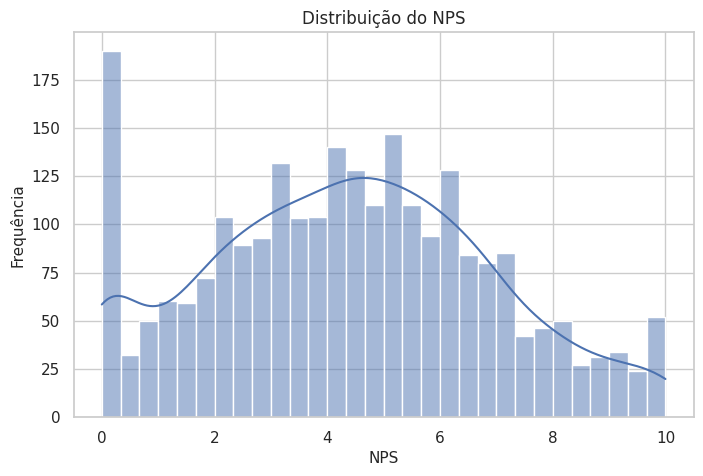

In [ ]:
# Visualizando o Histograma do NPS - visualizando suas frequências
sns.histplot(data=df, x='nps', bins=30, kde=True)
plt.title('Distribuição do NPS')
plt.xlabel('NPS')
plt.ylabel('Frequência')
plt.show()

### Análise de dispersão do NPS

Foi utilizado um boxplot para visualizar a dispersão dos dados de NPS.

O gráfico permite identificar:
- Mediana
- Intervalo interquartil (IQR)
- Possíveis outliers

Observação:
Os valores de NPS apresentam uma distribuição relativamente ampla, com variação entre 0 e 10, sem presença significativa de outliers extremos.

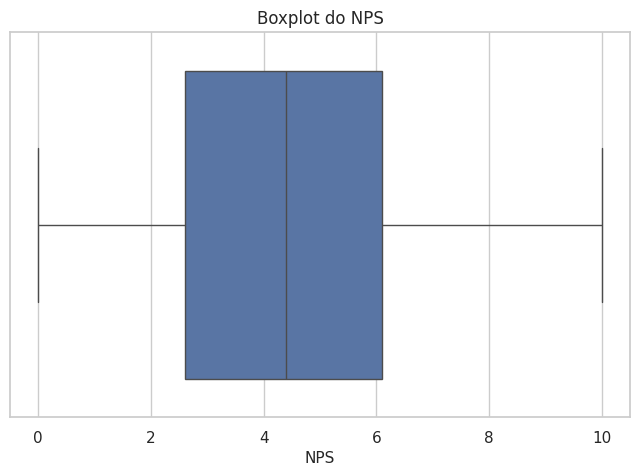

In [ ]:
# Visualizando o Boxplot
sns.boxplot(data=df, x='nps')
plt.title('Boxplot do NPS')
plt.xlabel('NPS')
plt.show()

### Métricas resumo do NPS

Foram calculadas métricas principais do NPS utilizando agregações:

- Média: 4.38  
- Mediana: 4.40  
- Mínimo: 0  
- Máximo: 10  

In [ ]:
df['nps'].agg(['mean', 'median', 'min','max']).round(2)

,nps
mean,4.38
median,4.40
min,0.00
max,10.00


## 3.4. Classificação do NPS



### Classificação do NPS

Foi criada uma nova variável categórica (`classe`) a partir dos valores de NPS, segmentando os clientes em três grupos:

- Detratores (0 a 6)
- Neutros (6 e 8)
- Promotores (8 e 10)

Essa classificação segue o padrão de mercado utilizado para análise de satisfação do cliente.

In [ ]:
df['classe'] = pd.cut(df['nps'],
                      bins=[-1., 6., 8., np.inf],
                      labels=['Detratores', 'Neutros', 'Promotores'])

df.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,recompra_30_dias,numero_reclamacoes,pontuacao_csat_interno,classe
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Neutros
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detratores
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detratores
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detratores
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Neutros


### Distribuição dos classificadores

Foi realizada a contagem de clientes em cada categoria de NPS.

Resultado:
- Detratores: 1851
- Neutros: 448
- Promotores: 201

In [ ]:
# Verificando a contagem de cada classificador
df['classe'].value_counts().sort_values()

,count
classe,
Promotores,201
Neutros,448
Detratores,1851


### NPS médio por classificador

Foi calculada a média do NPS para cada grupo de classificação:

- Detratores: 3.26  
- Neutros: 6.89  
- Promotores: 9.10  

In [ ]:
# Verificando a média de cada classificador
media_nps = df.groupby('classe')['nps'].mean().sort_values().round(2)
media_nps

/tmp/ipykernel_23244/145288203.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_nps = df.groupby('classe')['nps'].mean().sort_values().round(2)


,nps
classe,
Detratores,3.26
Neutros,6.89
Promotores,9.10


### Comparação entre classificadores

Foi utilizado um gráfico de barras para comparar o NPS médio entre os grupos.

Insight:
Existe uma diferença clara entre os níveis de satisfação, evidenciando três perfis distintos de clientes:
- Insatisfeitos (Detratores)
- Moderadamente satisfeitos (Neutros)
- Altamente satisfeitos (Promotores)

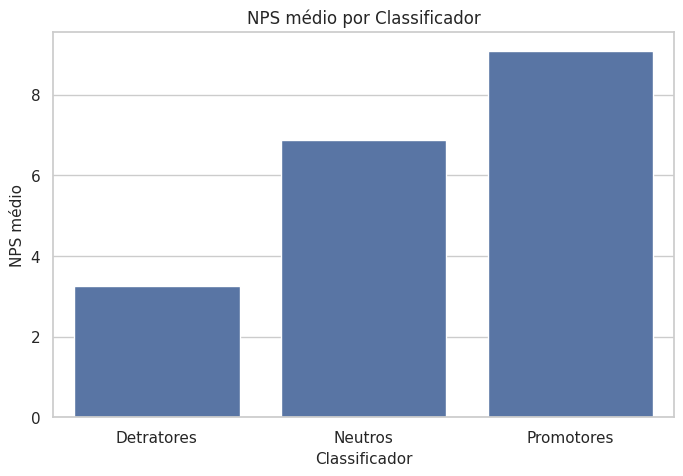

In [ ]:
sns.barplot(x=media_nps.index, y=media_nps.values)
plt.title('NPS médio por Classificador')
plt.xlabel('Classificador')
plt.ylabel('NPS médio')
plt.show()

### Distribuição do NPS por classificador

Foi utilizado um boxplot para analisar a dispersão do NPS dentro de cada grupo.

O gráfico mostra:
- Separação clara entre as categorias
- Baixa sobreposição entre os grupos
- Consistência na segmentação

Conclusão:
A classificação está bem definida e representa adequadamente os diferentes níveis de satisfação dos clientes.

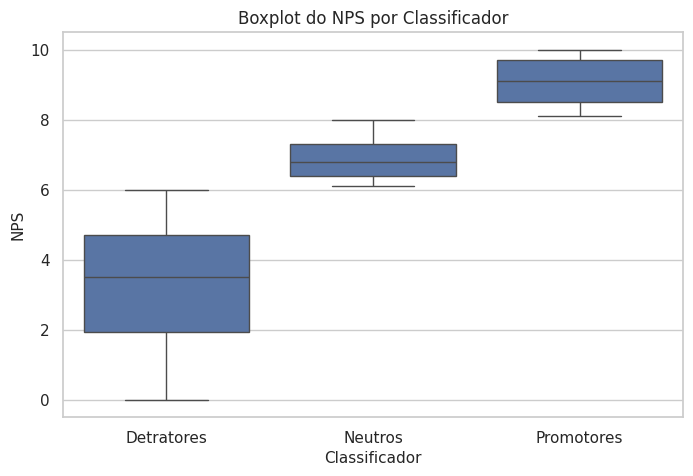

In [ ]:
sns.boxplot(data=df, x='classe', y='nps')
plt.title('Boxplot do NPS por Classificador')
plt.xlabel('Classificador')
plt.ylabel('NPS')
plt.show()

## 3.5. Fatores mais críticos para a satisfação



### Fatores críticos de satisfação por classificação de NPS (Boxplots)

Os boxplots apresentam a distribuição das variáveis operacionais — atraso na entrega, número de reclamações e CSAT — segmentadas por classificação de NPS.

Observa-se que:
- Clientes detratores apresentam maiores atrasos e maior número de reclamações  
- Clientes promotores possuem menores atrasos e menos reclamações  
- O CSAT é significativamente mais alto entre promotores  

Insight:
Os resultados indicam que eficiência operacional e qualidade do atendimento são fatores determinantes para a satisfação do cliente.

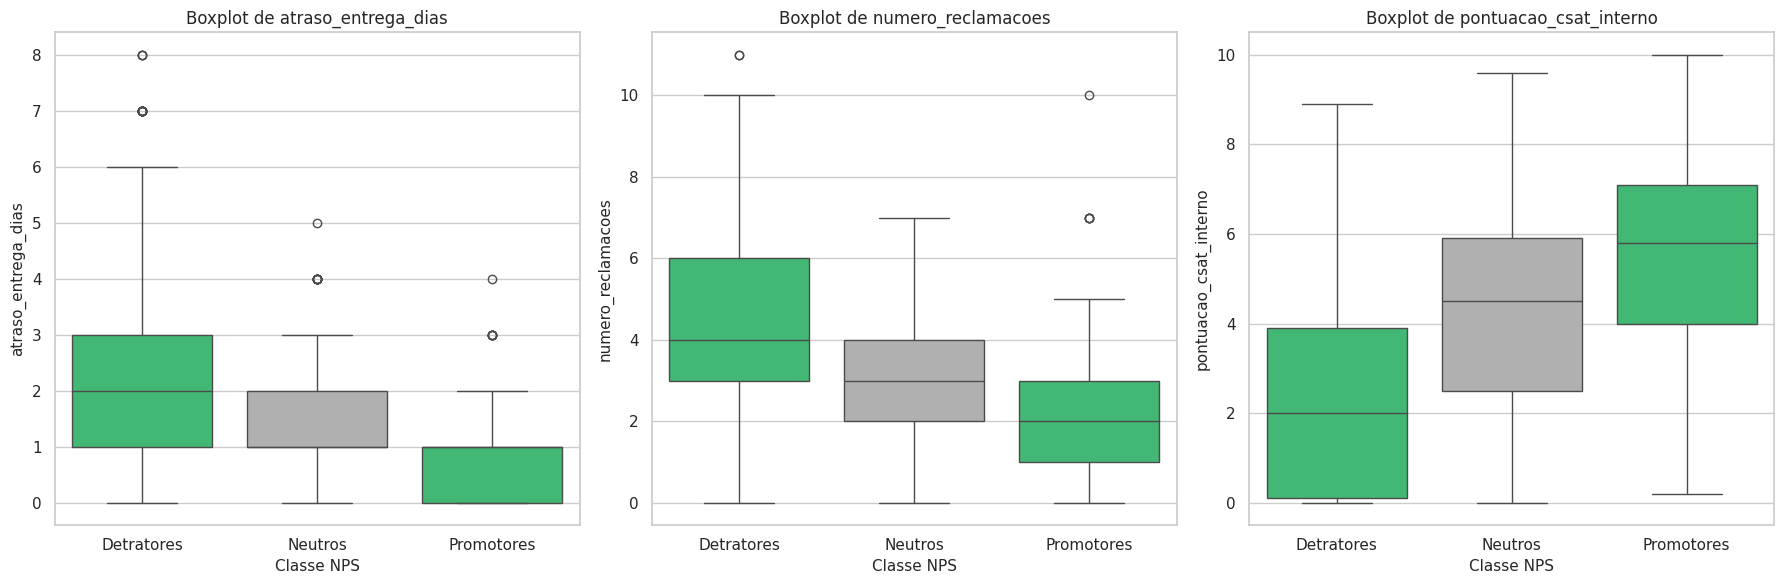

In [ ]:
# Visualizando o Boxplot e fazendo a comparação dos fatores mais críticos
fig, ax = plt.subplots(1, 3, figsize=(18,6))

colunas = ['atraso_entrega_dias', 'numero_reclamacoes', 'pontuacao_csat_interno']

palette = {
    'Detratores': '#2ecc71',
    'Neutros': '#b0b0b0',
    'Promotores': '#2ecc71'
}

for i, col in enumerate(colunas):
    order = ['Detratores', 'Neutros', 'Promotores']
    sns.boxplot(data=df, x='classe', y=col, order=order, ax=ax[i], palette=palette, legend=False, hue='classe')
    ax[i].set_title(f'Boxplot de {col}')
    ax[i].set_xlabel('Classe NPS')
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Distribuição dos fatores críticos por classificação de NPS (Violinplots)

Os violinplots permitem analisar a densidade e a distribuição dos dados para cada grupo de clientes.

Nota-se uma clara separação entre os perfis:
- Detratores concentram-se em maiores atrasos, mais reclamações e baixo CSAT  
- Promotores apresentam comportamento oposto, com melhor experiência geral  

Insight:
A consistência na operação e na experiência do cliente é essencial para reduzir detratores e aumentar promotores.

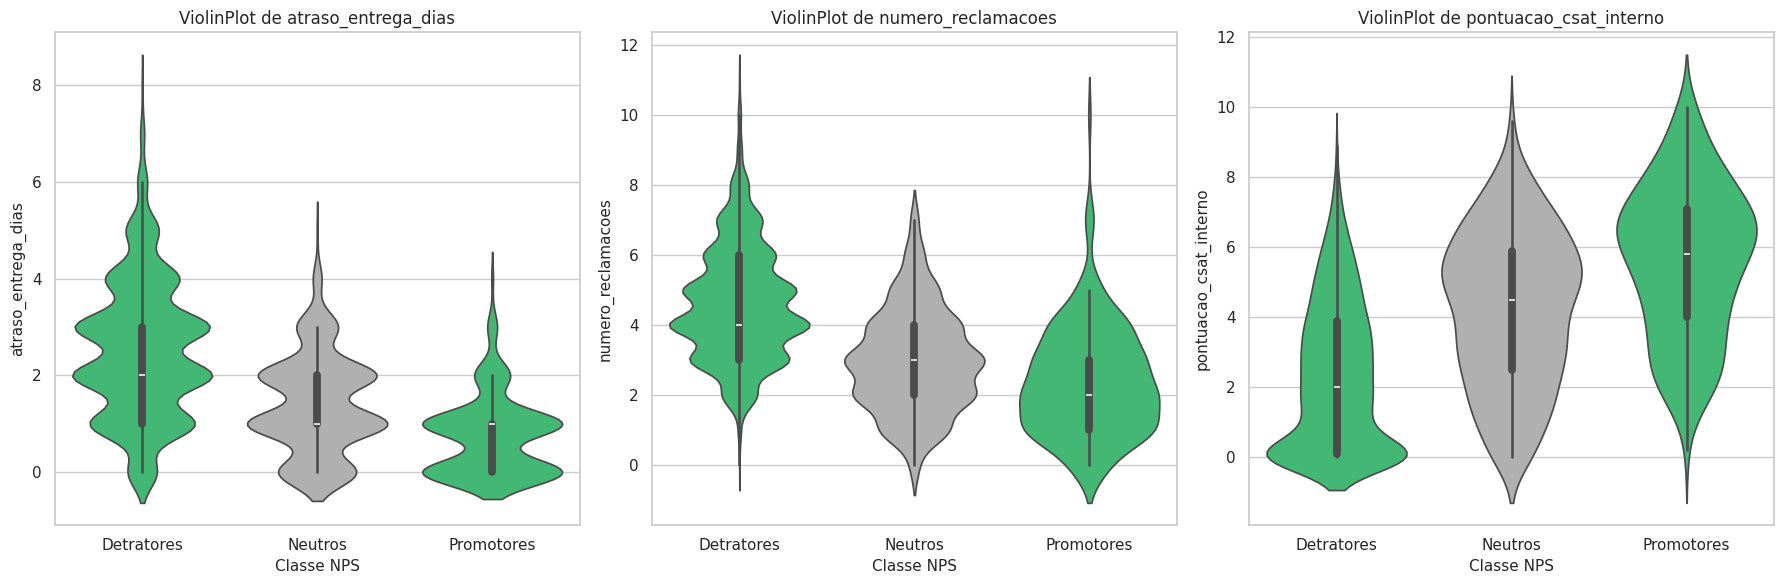

In [ ]:
# Visualizando o ViolinPlot e fazendo a comparação dos fatores mais críticos
fig, ax = plt.subplots(1, 3, figsize=(18,6))

colunas = ['atraso_entrega_dias', 'numero_reclamacoes', 'pontuacao_csat_interno']

palette = {
    'Detratores': '#2ecc71',
    'Neutros': '#b0b0b0',
    'Promotores': '#2ecc71'
}

for i, col in enumerate(colunas):
    order = ['Detratores', 'Neutros', 'Promotores']
    sns.violinplot(data=df, x='classe', y=col, order=order, ax=ax[i], palette=palette, hue='classe')
    ax[i].set_title(f'ViolinPlot de {col}')
    ax[i].set_xlabel('Classe NPS')
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 3.6. Explorando o que mais gera detratores



In [ ]:
def plot_detratores(df, x, y):
  fig, ax = plt.subplots(1, 3, figsize=(18,6))


  palette = {
      'Detratores': '#2ecc71',
      'Neutros': '#b0b0b0',
      'Promotores': '#b0b0b0'
  }

  order = ['Detratores', 'Neutros', 'Promotores']
  # BOXPLOT
  sns.boxplot(data=df, x=x, y=y, order=order, ax=ax[0], palette=palette, legend=False, hue=x)
  ax[0].set_title(f'Boxplot de {y}')
  ax[0].set_xlabel('Classe NPS')
  ax[0].set_ylabel(y)

  # VIOLINPLOT
  sns.violinplot(data=df, x=x, y=y, order=order, ax=ax[1], palette=palette, legend=False, hue=x)
  ax[1].set_title(f'ViolinPlot de {y}')
  ax[1].set_xlabel('Classe NPS')
  ax[1].set_ylabel(y)

  # DENSIDADE - KDEPLOT
  sns.kdeplot(data=df, x=y, hue=x, ax=ax[2], fill=True)
  ax[2].set_title(f'Gráfico de Densidade de {y}')
  ax[2].set_ylabel(y)

  plt.tight_layout()
  plt.show()


### Impacto do atraso na entrega nos detratores

A análise mostra que clientes detratores apresentam maiores níveis de atraso na entrega, com distribuição mais ampla e presença de valores elevados.

Enquanto promotores concentram-se em baixos níveis de atraso, os detratores enfrentam maior inconsistência no prazo de entrega.

Insight:
Atrasos frequentes e falta de previsibilidade na entrega impactam negativamente a experiência do cliente, sendo um dos principais fatores que geram detratores.

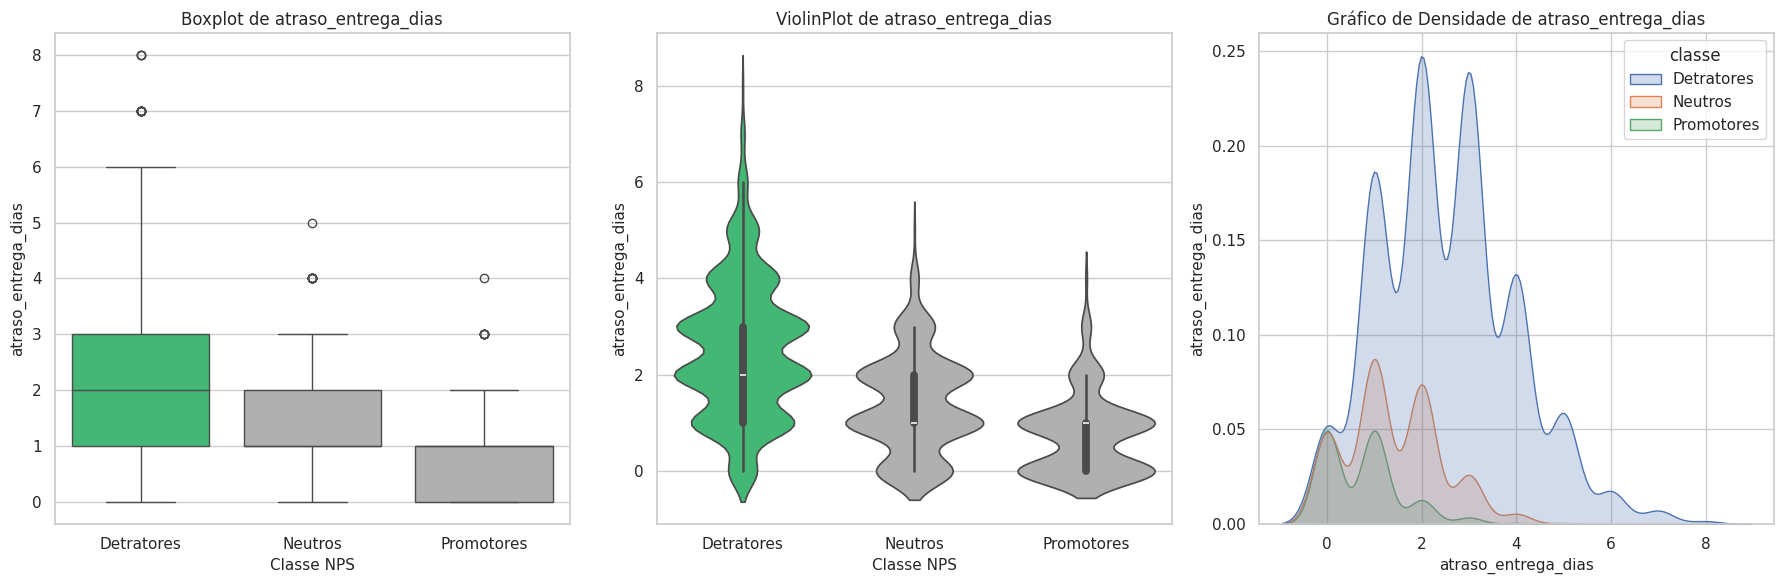

In [ ]:
plot_detratores(df, 'classe', 'atraso_entrega_dias')

### Impacto do número de reclamações nos detratores

Os clientes detratores possuem maior volume de reclamações, além de maior dispersão nos dados, indicando recorrência de problemas.

Em contraste, promotores apresentam baixa frequência de reclamações, sugerindo uma jornada mais fluida.

Insight:
O acúmulo de problemas ao longo da jornada do cliente aumenta significativamente a probabilidade de insatisfação, tornando o número de reclamações um forte indicador de detratores.

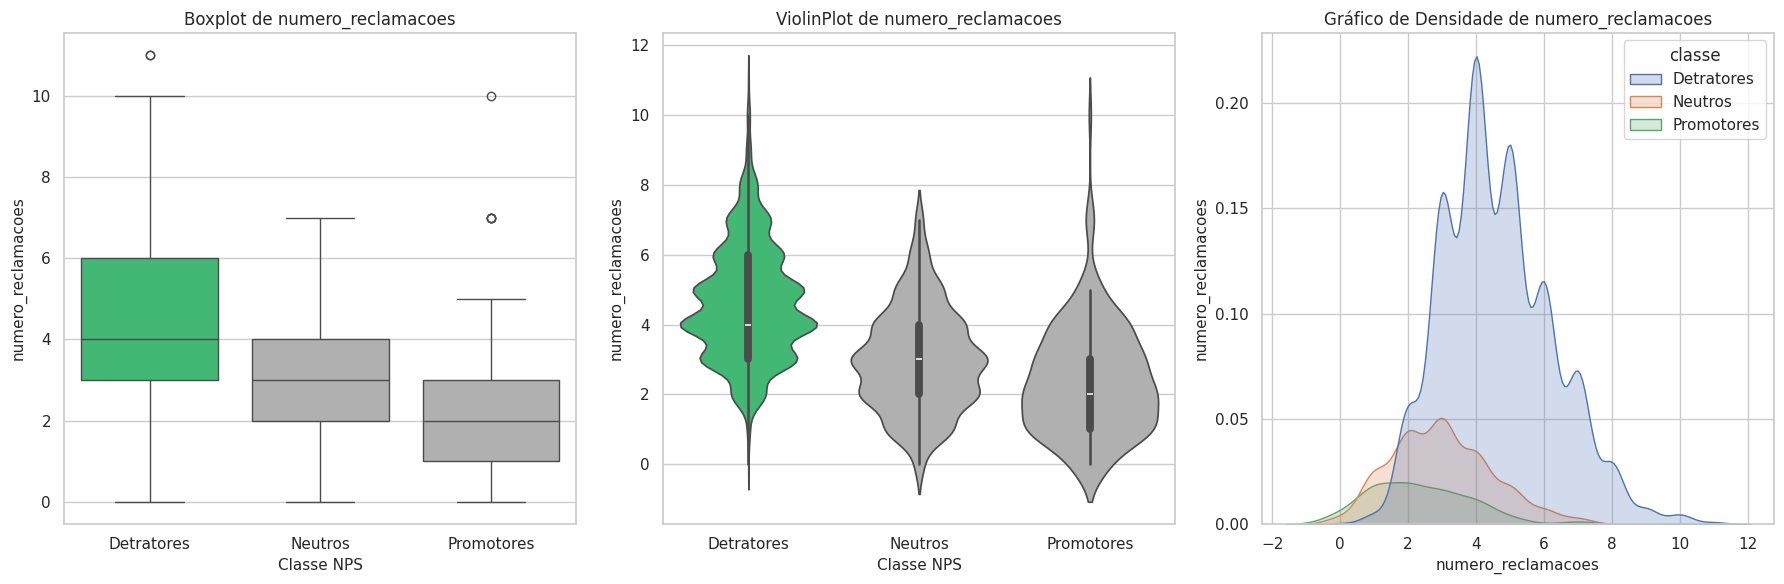

In [ ]:
plot_detratores(df, 'classe', 'numero_reclamacoes')

### Impacto do CSAT interno nos detratores

Os detratores apresentam baixos níveis de satisfação no atendimento (CSAT), com concentração em notas reduzidas.

Já os promotores possuem avaliações significativamente mais altas, evidenciando uma melhor experiência de suporte.

Insight:
A baixa qualidade no atendimento é um fator crítico na formação de detratores, indicando que falhas na resolução de problemas agravam a insatisfação do cliente.

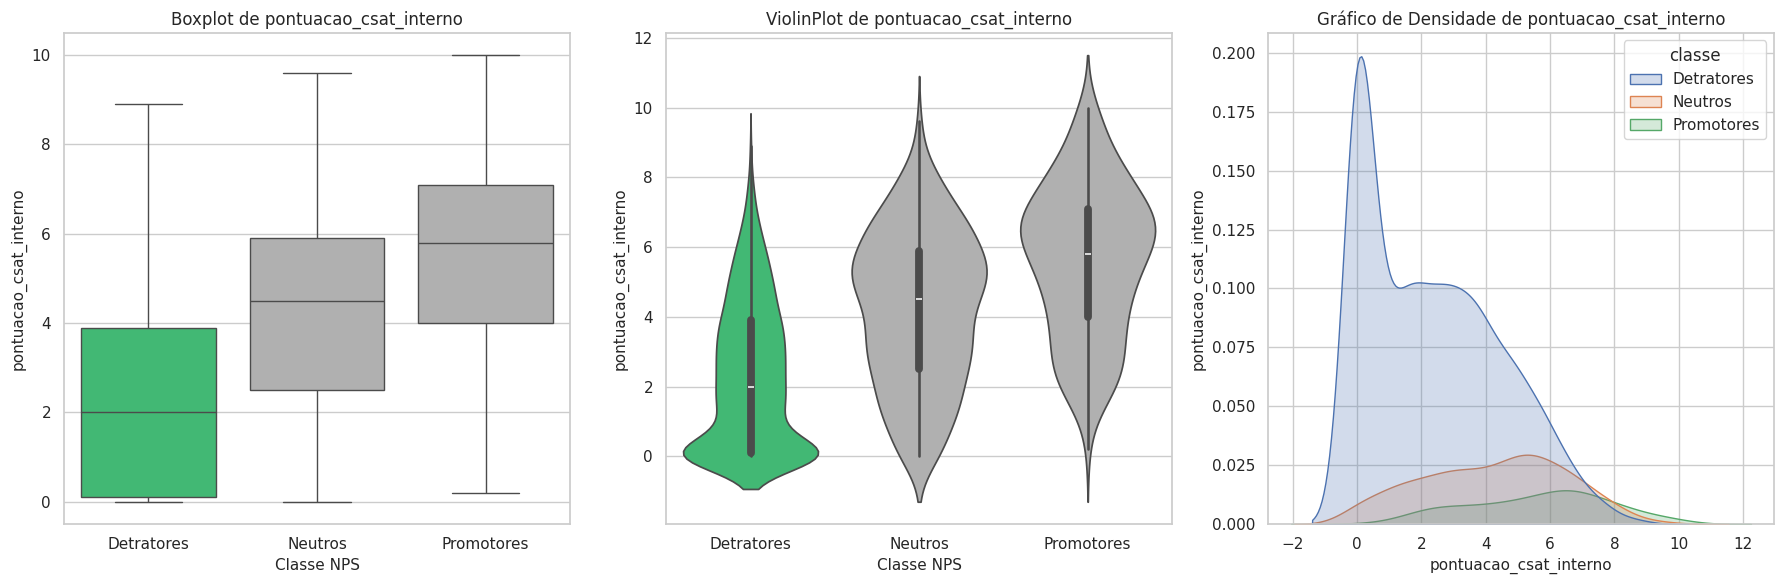

In [ ]:
plot_detratores(df, 'classe', 'pontuacao_csat_interno')

## 3.7. Analisando o Ponto de Ruptura


Após identificar os principais fatores que influenciam a satisfação do cliente, foi analisada a relação entre a pontuação de satisfação interna (CSAT) e a classificação do NPS, com o objetivo de identificar possíveis pontos de ruptura na experiência do cliente.

Para isso, a variável CSAT foi segmentada em faixas, permitindo observar a variação na proporção de Detratores, Neutros e Promotores.

A análise evidencia um padrão claro:
- Baixos níveis de CSAT (0–4) concentram alta proporção de detratores  
- À medida que o CSAT aumenta, há redução gradual de detratores e aumento de promotores  

Observa-se uma mudança significativa a partir da faixa de CSAT 6–8:
- Queda expressiva na proporção de detratores  
- Crescimento relevante de promotores  

In [ ]:
df['CSAT'] = pd.cut(df['pontuacao_csat_interno'],
                    bins=[0., 2., 4., 6., 8., np.inf],
                    labels=['0-2', '2-4', '4-6', '6-8', '8-10'])

df.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,recompra_30_dias,numero_reclamacoes,pontuacao_csat_interno,classe,CSAT
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Neutros,6-8
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detratores,NaN
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detratores,0-2
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detratores,0-2
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Neutros,6-8


In [ ]:
pd.crosstab(df['CSAT'], df['classe'], normalize='index').round(2)

classe,Detratores,Neutros,Promotores
CSAT,,,
0-2,0.84,0.13,0.02
2-4,0.77,0.17,0.06
4-6,0.62,0.28,0.10
6-8,0.36,0.36,0.28
8-10,0.14,0.23,0.63


Conclusão:
Existe um ponto de ruptura na experiência do cliente em torno de CSAT 6, a partir do qual pequenas melhorias na satisfação geram mudanças significativas no comportamento do cliente.

Implicação de negócio:
Manter o CSAT acima desse nível é essencial para reduzir detratores e aumentar a base de promotores.

## 3.8 Que tipo de Cliente tende a ter NPS mais alto ou mais baixo?

### ● Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

**Resposta:**  
Clientes com NPS mais alto tendem a ter uma experiência mais positiva ao longo da jornada. Em geral, são aqueles que apresentam:

- Menor número de reclamações  
- Pouco ou nenhum atraso na entrega  
- Menor necessidade de contato com o atendimento  
- Maiores níveis de satisfação interna (CSAT)  

Esses fatores indicam uma operação mais eficiente e uma experiência sem atritos, aumentando a chance de o cliente se tornar promotor.

Por outro lado, clientes com NPS mais baixo (detratores) geralmente apresentam:

- Maior número de reclamações  
- Atrasos na entrega  
- Mais interações com o atendimento  
- Baixos níveis de satisfação interna (CSAT)  

Além disso, foi identificado um possível ponto de ruptura relacionado ao CSAT: clientes com pontuação abaixo de aproximadamente 6 tendem a concentrar maior proporção de detratores, enquanto acima desse nível há aumento significativo de promotores.